In [1]:
library(ggClusterNet)
library(SpiecEasi)
library(phyloseq)
library(igraph)
library(tidyverse)


Attaching package: 'igraph'


The following object is masked from 'package:SpiecEasi':

    make_graph


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%--%()      masks igraph::%--%()
✖ ggplot2::alpha()       masks ggClusterNet::alpha()
✖ dplyr::as_data_frame() masks tibble::as_data_frame(), igraph::as_data_frame()
✖ purrr::compose()       masks igraph::compose()
✖ tidyr::crossing()      masks igraph::crossing()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ purrr::simplify()      masks ig

## <font color=lightgreen> Custom function

### SparCC function

In [2]:
sparcc.micro_ls <- function(
  data = data,
  R = 10,
  ncpus = 1,
  method.adjust = "fdr" 
){
  spmatrix <- SpiecEasi::sparcc(data)

  tp0 <- proc.time()
  sp.boot <- SpiecEasi::sparccboot(
    data,
    R = R,
    ncpus = ncpus
  )
  tp1 <- proc.time()
  # print(tp1 - tp0)

  sp.p <- SpiecEasi::pval.sparccboot(sp.boot, sided = "both")

  cors <- sp.p$cors
  sp.p$pvals[is.na(sp.p$pvals)] = 1
  

  pvals <- p.adjust(sp.p$pvals, method = method.adjust)
  # ------------------------------


  sparCCpcors <- diag(1, nrow = dim(spmatrix$Cor)[1], ncol = dim(spmatrix$Cor)[1])
  sparCCpcors[upper.tri(sparCCpcors, diag=FALSE)] <- cors
  sparCCpcors <- t(sparCCpcors)
  sparCCpcors[upper.tri(sparCCpcors, diag=FALSE)] <- cors


  sparCCpval <- diag(0, nrow = dim(spmatrix$Cor)[1], ncol = dim(spmatrix$Cor)[1])
  sparCCpval[upper.tri(sparCCpval, diag=FALSE)] <- pvals
  sparCCpval <- t(sparCCpval)
  sparCCpval[upper.tri(sparCCpval, diag=FALSE)] <- pvals

  rownames(sparCCpcors) <- colnames(data)
  colnames(sparCCpcors) <- colnames(data)
  rownames(sparCCpval) <- colnames(data)
  colnames(sparCCpval) <- colnames(data)

  reordered_all_sparcc <- reorder_cor_and_p(sparCCpcors, sparCCpval)
  occor.r <- reordered_all_sparcc$r
  occor.p <- reordered_all_sparcc$p

  return(list(occor.r, occor.p))
}

### Correlation function

In [3]:
corMicro_ls = function(ps = ps,N = 0,r.threshold=0.6,
                    method.scale = "rela",
                    p.threshold=0.05,method = "pearson",R = 10,ncpus = 1, method.adjust = "fdr"){



  if (method %in% c("pearson","spearman","kendall")) {
    # ps_rela  = transform_sample_counts(ps, function(x) x / sum(x) )
    # ps_rela  = scale_micro(ps = ps,method = method.scale)
    ps_sub = filter_OTU_ps(ps = ps,Top = N)
    otu_table = as.data.frame(t(vegan_otu(ps_sub)))
    head(otu_table)
    #--- use corr.test function to calculate relation#--------
    occor = psych::corr.test(t(otu_table),use="pairwise",method=method,adjust="fdr",alpha=.05)
    occor.r = occor$r
    occor.p = occor$p

  }

  if (method %in% c("sparcc")) {
    ps_sub = filter_OTU_ps(ps = ps,Top = N)
    otu_table = as.data.frame(t(vegan_otu(ps_sub)))
    head(otu_table)
    result <- sparcc.micro_ls(data = t(otu_table),R = R,ncpus = ncpus, method.adjust = method.adjust)
    occor.r = result[[1]]
    occor.p = result[[2]]
  }
  # occor.r[occor.p > p.threshold & abs(occor.r)<r.threshold] = 0
  occor.r[occor.p > p.threshold | abs(occor.r)<r.threshold] = 0
  return(list(occor.r,method,ps_sub,occor.p))

}





get_lower_tri<-function(cormat){
  cormat[upper.tri(cormat)] <- NA
  return(cormat)
}
# Get upper triangle of the correlation matrix
get_upper_tri <- function(cormat){
  cormat[lower.tri(cormat)]<- NA
  return(cormat)
}

reorder_cormat <- function(cormat){
  # Use correlation between variables as distance
  dd <- as.dist((1-cormat)/2)
  hc <- hclust(dd)
  cormat <-cormat[hc$order, hc$order]
}

reorder_cor_and_p <- function(cormat, pmat){
  dd <- as.dist((1-cormat)/2)
  hc <- hclust(dd)
  cormat <-cormat[hc$order, hc$order]
  pmat <- pmat[hc$order, hc$order]
  list(r = cormat, p = pmat)
}


### Pipline function

In [4]:

#' Microbial related network
#'
#' @param ps phyloseq Object, contains OTU tables, tax table and map table, represented sequences,phylogenetic tree.
#' @param N filter OTU tables by abundance.The defult, N=0, extract the top N number relative abundance of OTU. e.g 100
#' @param r.threshold The defult, r.threshold=0.6, it represents the correlation that the absolute value
#'  of the correlation threshold is greater than 0.6. the value range of correlation threshold from 0 to 1.
#' @param p.threshold The defult, p.threshold=0.05, it represents significance threshold below 0.05.
#' @param select_layout  TURE or FALSE
#' @param layout_net defult "model_maptree"
#' @param method method for Correlation calculation,method="pearson" is the default value. The alternatives to be passed to cor are "spearman" and "kendall".
#' @param label Whether to add node label.
#' @param group Separate Group.
#' @param lay layout which network show
#' @param path save path of all of network analyse.
#' @param fill fill coulor of node
#' @param size node size
#' @param zipi zipi Calculation
#' @param step Random network sampling times
#' @param R repeat number of p value calculate
#' @param ncpus number of cpus used for sparcc
#' @param layout_net select layout from ggClusterNet
#' @param big TRUE or FALSE the number of micro data was so many (> 300),you can chose TREU
#' @examples
#' data(ps)
#' result = network.pip(ps = ps,N = 100,r.threshold=0.6,big = T,
#'                    select_layout = T,
#'                    p.threshold=0.05,label = FALSE,zipi = F)
#' result[[1]]
#' result[[2]]
#' @return list which contains OTU correlation matrix
#' @author Contact: Tao Wen \email{taowen@@njau.edu.cn} Penghao Xie \email{2019103106@@njau.edu.cn} yongxin liu \email{yxliu@@genetics.ac.cn} Jun Yuan \email{junyuan@@njau.edu.cn}
#' @references
#'
#' Tao Wen#, Penghao Xie#, Shengdie Yang, Guoqing Niu, Xiaoyu Liu, Zhexu Ding, Chao Xue, Yong-Xin Liu *, Qirong Shen, Jun Yuan*
#' ggClusterNet: an R package for microbiome network analysis and modularity-based multiple network layouts
#' iMeta 2022,DOI: \url{doi: 10.1002/imt2.32}
#' @export




network.pip_ls = function(
    otu = NULL,
    tax = NULL,
    map = NULL,
    ps = NULL,
    N = 0,
    ra = NULL,
    order = NULL ,
    big = TRUE,
    select_layout = FALSE,
    layout_net = "model_maptree2",
    r.threshold = 0.6,
    p.threshold = 0.05,
    maxnode = 2,
    method = "spearman",
    label = FALSE,
    lab = "elements",
    group = "Group",
    fill = "Phylum",
    size = "igraph.degree",
    zipi = FALSE,
    clu_method = "cluster_fast_greedy",
    step = 100,
    ram.net = FALSE,
    method.adjust = "fdr",
    R,
    ncpus
){

  ps = inputMicro(otu,tax,map,tree,ps,group  = group)
  # if (scale ) {ps_rela  = scale_micro(ps = ps,method = "rela")} else {ps_rela <- ps}
  mapping = as.data.frame(sample_data(ps))
  y = matrix(1,nrow = 16,ncol = length(unique(mapping$Group)))
  layouts = as.character(unique(mapping$Group))
  mapping$ID = row.names(mapping)
  # plots = list()
  # plots1 = list()
  # aa = 1
  # layout = layouts[2]
  cor.all = list()
  for (layout in layouts) {

    mapi <- mapping[mapping$Group ==  layout,]


    # psi = phyloseq(otu_table(ps),
    #                tax_table(ps),
    #                sample_data(mapi)
    # ) %>%
    #   filter_OTU_ps(Top = N) %>%
    #   filter_taxa( function(x) sum(x ) > 0 , TRUE)


    if (!is.null(N)) {
      psi = phyloseq(otu_table(ps),
                     phyloseq::tax_table(ps),
                     sample_data(mapi)
      ) %>%
        filter_OTU_ps(Top = N) %>%
        filter_taxa( function(x) sum(x ) > 0 , TRUE)
    } else if (!is.null(ra)) {
      res = select.otu.g(ps = ps,ra = ra,id = group)
      map = phyloseq::sample_data(ps)
      # gc = map[,group] %>% as.vector() %>%.[[1]] %>% unique()
      psi =  ps %>%
        subset_samples.wt(group,layout) %>%
        subset_taxa.wt("OTU",res[[layout]])

    }




    print(layout)

    if (big == TRUE) {

      if (method == "sparcc") {
        result = corMicro_ls (ps = psi,N = 0,r.threshold= r.threshold,p.threshold=p.threshold,
                           method = method,R = R,ncpus = ncpus)

        }else{
          result = cor_Big_micro(ps = psi,N = 0,r.threshold= r.threshold,p.threshold=p.threshold,method = method,scale = FALSE)
        }



      a = 2} else if(big == FALSE){
        result = corMicro_ls (ps = psi,N = 0,r.threshold= r.threshold,p.threshold=p.threshold,
                           method = method,R = R,ncpus = ncpus, method.adjust = method.adjust

                           )
        a = 1}

    print("cor matrix culculating over")
    cor = result[[1]]    #Extract correlation matrix

    cor[is.na(cor)] = 0
    if (cor %>% as.vector() %>% max() == 0) {
      stop("The connect value in cor matrix all was zone")
    }

    tem = paste(layout,sep = ".")
    cor.all[[tem]] = cor

    #--构造边和节点文件，全部放到一起
    res = node.edge(
      cor = cor,
      select_layout = TRUE,
      clu_method=clu_method,
      layout_net = layout_net
    )

    nod = res[[1]]
    nod$group = tem
    edg = res[[2]]
    edg$group = tem

    if (layout == layouts[1]) {
      node = nod
      edge = edg
    } else{
      node = rbind(node,nod)
      edge = rbind(edg,edge)
    }
  }
  head(edge)

  # tax = ps %>% vegan_tax() %>% as.data.frame() %>%
  #   rownames_to_column("ID")
  tax <- ps %>%
    vegan_tax() %>%
    as.data.frame() %>%
    {
      if ("ID" %in% colnames(.)) {
        rename(., ID0 = ID)
      } else {
        .
      }
    } %>%
    rownames_to_column("ID")




  node$ID = node$elements
  node.1 = node  %>%
    dplyr::left_join(tax,by = "ID")
  head(node.1)

  node.1$Group = node.1$group
  # node.1$time = sapply(strsplit(node.1$group, "[.]"), `[`, 2)
  # node.1$space = sapply(strsplit(node.1$group, "[.]"), `[`, 1)

  edge$Group = edge$group
  # edge$time = sapply(strsplit(edge$group, "[.]"), `[`, 2)
  # edge$space = sapply(strsplit(edge$group, "[.]"), `[`, 1)

  head(edge)
  #-统计边的节点数量 node link
  tem = edge$group %>% table() %>% as.data.frame()
  colnames(tem) = c("group","links")
  i = 1
  id = edge$group %>% unique()
  aa = c()
  for (i in 1:length(id)) {
    aa[i] = edge %>%
      dplyr::filter(group == id[i]) %>%
      dplyr::select("OTU_2", "OTU_1") %>% as.matrix() %>%
      as.vector() %>% unique() %>% length()
  }
  tem2 = data.frame(group = id,nodes = aa)

  tem3 = tem2# %>% full_join(tem2,by = "group")
  tem3$label= paste(tem3$group,": (nodes: ",
                    tem3$nodes,"; links: ",tem$links,")",sep = "")


if ( is.null(order) ) {
  node.1$group = factor(node.1$group)
  edge$group = factor(edge$group)
} else{
  node.1$group = factor(node.1$group,levels = order)
  edge$group = factor(edge$group,levels = order)
}


  # tem3 = tem3[match(a,tem3$order),]
  tem3$label = factor(tem3$label,levels = tem3$label)
  edge = edge %>% left_join(tem3,by = "group")
  # head(edge)
  edge$label = factor(edge$label,levels = as.character(tem3$label))


  node.1 = node.1 %>% left_join(tem3,by = "group")
  node.1$label = factor(node.1$label,levels = as.character(tem3$label))



  net.dat.1 = list(
    cortab = cor.all,
    node = node.1,
    edge = edge
  )

  p1 <- ggplot() + geom_segment(aes(x = X1, y = Y1, xend = X2, yend = Y2,
                                    color = cor),
                                data = edge, size = 0.03,alpha = 0.5) +
    geom_point(aes(X1, X2,
                   fill = !!sym(fill),
                   size = !!sym(size) ),
               pch = 21, data = node.1,color = "gray40") +
    facet_wrap(.~ label,scales="free_y") +
    # geom_text_repel(aes(X1, X2,label = elements),pch = 21, data = nodeG) +
    # geom_text(aes(X1, X2,label = elements),pch = 21, data = nodeG) +
    scale_colour_manual(values = c("#6D98B5","#D48852")) +
    scale_size(range = c(0.8, maxnode)) +
    scale_x_continuous(breaks = NULL) +
    scale_y_continuous(breaks = NULL) +
    theme(panel.background = element_blank(),
          plot.title = element_text(hjust = 0.5)
    ) +
    theme(axis.title.x = element_blank(),
          axis.title.y = element_blank()
    ) +
    theme(legend.background = element_rect(colour = NA)) +
    theme(panel.background = element_rect(fill = "white",  colour = NA)) +
    theme(panel.grid.minor = element_blank(), panel.grid.major = element_blank())
  p1

  if (label == TRUE) {
    p1 = p1 + ggrepel::geom_text_repel(aes(X1, X2,label = elements),pch = 21, data = node.1)
  }
  #--net propeties#----
  i = 1

  dat.net = list()
  for (i in 1:length(names(cor.all))) {
    igra = make_igraph(cor.all[[names(cor.all)[i]]])
    tem = net_properties.4(igra)
    colnames(tem) = names(cor.all)[i]
    dat.net[[names(cor.all)[i]]] = tem
  }
  net.dat.2 <- do.call(cbind,dat.net)
  net.dat.2
  #--node propeties#-----
  dat.net = list()
  for (i in 1:length(names(cor.all))) {
    igra = make_igraph(cor.all[[names(cor.all)[i]]])
    tem = node_properties(igra) %>% as.data.frame()
    tem$group = names(cor.all)[i]
    tem$ID = row.names(tem)
    # colnames(tem) = paste(names(cor.all)[i],colnames(tem),sep = "_")
    dat.net[[names(cor.all)[i]]] = tem

  }
  net.dat.3 <- do.call(rbind,dat.net)
  # dim(net.dat.3)

  # i = 1
  if (zipi ) {
    dat.net = list()
    for (i in 1:length(names(cor.all))) {
      igra = make_igraph(cor.all[[names(cor.all)[i]]])
      #----culculate zi pi
      res = ZiPiPlot(igraph = igra,method = clu_method)
      # p <- res[[1]]
      # ggsave(paste(path,"/",layout,"_ZiPi.pdf",sep = ""),p,width = 12, height = 10)
      tem <- res[[2]]
      tem$group = names(cor.all)[i]
      tem$id = row.names(tem)
      dat.net[[names(cor.all)[i]]] = tem
    }
    net.dat.4 <- do.call(rbind,dat.net)
    # head(net.dat.4)
    p2 = facet.zipi(net.dat.4= net.dat.4)
    p2

  } else{
    net.dat.4 <- NULL
    p2 = NULL
  }


  # random network#----


  if (ram.net) {
    dat.net = list()
    dat.net2 = list()
    for (i in 1:length(names(cor.all))) {
      igra = make_igraph(cor.all[[names(cor.all)[i]]])
      result = random_Net_compate(igraph = igra,
                                  type = "gnm",
                                  step = 100, netName = "network")
      # p1 = result[[1]]
      tem = result[[2]]
      tem$g = names(cor.all)[i]
      dat.net[[names(cor.all)[i]]] = tem

      tem2 = result[[4]] %>% as.data.frame()
      tem2
      colnames(tem2)[1] = "network"
      # colnames(tem2) = paste(names(cor.all)[i], colnames(tem2),sep = "_")
      tem2$g = names(cor.all)[i]
      tem2$prop = row.names(tem2)
      dat.net2[[names(cor.all)[i]]] = tem2
    }
    net.dat.5 <- do.call(rbind,dat.net)
    net.dat.6 <- do.call(rbind,dat.net2)
    p3 <- ggplot(net.dat.5) +
      geom_point(aes(x = ID,y = network,
                     group =group,fill = group),pch = 21,size = 2) +
      geom_smooth(aes(x = ID,y = network,group =group,color = group))+
      facet_grid(.~g,scales = "free") +
      theme_bw() + theme(
        plot.margin=unit(c(0,0,0,0), "cm")
      )
    p3
  } else{
    net.dat.5 <- NULL
    net.dat.6 <- NULL
    p3 = NULL
  }



  net.all = list(net.cor.matrix = net.dat.1,
                 net.properties = net.dat.2,
                 node.properties = net.dat.3,
                 zipi.data = net.dat.4,
                 random.net.data = net.dat.5,
                 random.net.properties = net.dat.6)
  plots = list(net.plot = p1,
               zipi = p2,
               random.plot = p3

  )
  return(list(plots,net.all))

}


facet.zipi = function(
    net.dat.4= net.dat.4
){
  x1<- c(0, 0.62,0,0.62)
  x2<- c( 0.62,1,0.62,1)
  y1<- c(-Inf,2.5,2.5,-Inf)
  y2 <- c(2.5,Inf,Inf,2.5)
  lab <- c("peripheral",'Network hubs','Module hubs','Connectors')

  roles.colors <- c("#E6E6FA","#DCDCDC","#F5FFFA", "#FAEBD7")


  tab = data.frame(x1 = x1,y1 = y1,x2 = x2,y2 = y2,lab = lab)
  tem = net.dat.4$group %>% unique() %>% length()
  for ( i in 1:tem) {
    if (i == 1) {
      tab2 = tab
    } else{
      tab2 = rbind(tab2,tab)
    }
  }


  p <- ggplot() +
    geom_rect(data=tab2,
              mapping=aes(xmin=x1,
                          xmax=x2,
                          ymin=y1,
                          ymax=y2,
                          fill = lab))+
    guides(fill=guide_legend(title="Topological roles")) +
    scale_fill_manual(values = roles.colors)+
    geom_point(data=net.dat.4,aes(x=p, y=z,color=module)) + theme_bw()+
    guides(color= FALSE) +
    ggrepel::geom_text_repel(data = net.dat.4,
                             aes(x = p, y = z,
                                 color = module,label=label),size=4)+
    # facet_wrap(.~group) +
    facet_grid(.~ group, scale='free') +
    theme(strip.background = element_rect(fill = "white"))+
    xlab("Participation Coefficient")+ylab(" Within-module connectivity z-score")
  return(p)
}



## <font color=lightgreen> Code

In [5]:
setwd("共生网络")

In [6]:
otu_p <- as.matrix(read.table("asv_filt.csv", header = TRUE, sep = ",", row.names = 1))
#head(otu_p)
tax_p <- as.matrix(read.table("asv_tax.csv", header = TRUE, sep = ",", row.names = 1))
#head(tax_p)
meta_p <- read.delim("./metadata.tsv", row.names = 1)
#head(meta_p)
OTU = otu_table(otu_p, taxa_are_rows = TRUE)
TAX = tax_table(tax_p)
META = sample_data(meta_p)
ps = phyloseq(OTU, TAX, META)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 392 taxa and 24 samples ]
sample_data() Sample Data:       [ 24 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 392 taxa by 8 taxonomic ranks ]

In [7]:
net_res = network.pip_ls(ps = ps,
                    N = 0, big = F, select_layout = F, layout_net = "model_maptree2", r.threshold = 0.7, p.threshold = 0.01, method = "sparcc",
                    maxnode = 2, label = F, lab = "element", group = "Group", fill = "phylum",size = "igraph.degree", zipi = T, ram.net = T, clu_method = "cluster_fast_greedy",
                    step = 100, R = 10, ncpus = 5, method.adjust = "fdr")

#saveRDS(net_res,"network.pip.sparcc.by.FDR.rds")

[1] "Ctrl"
[1] "cor matrix culculating over"


Warning message:
"Setting row names on a tibble is deprecated."
Joining with `by = join_by(ID)`
Joining with `by = join_by(ID)`
Non-leaf weights ignored
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."


[1] "Model"
[1] "cor matrix culculating over"


Warning message:
"Setting row names on a tibble is deprecated."
Joining with `by = join_by(ID)`
Joining with `by = join_by(ID)`
Non-leaf weights ignored
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."


[1] "Soyb"
[1] "cor matrix culculating over"


...

Warning message:
"Setting row names on a tibble is deprecated."
Joining with `by = join_by(ID)`
Joining with `by = join_by(ID)`
Non-leaf weights ignored
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."


[1] "L_CBD"
[1] "cor matrix culculating over"


Warning message:
"Setting row names on a tibble is deprecated."
Joining with `by = join_by(ID)`
Joining with `by = join_by(ID)`
Non-leaf weights ignored
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."


[1] "H_CBD"
[1] "cor matrix culculating over"


Warning message:
"Setting row names on a tibble is deprecated."
Joining with `by = join_by(ID)`
Joining with `by = join_by(ID)`
Non-leaf weights ignored
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Setting row names on a tibble is deprecated."
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
Warning message:
"The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the ggClusterNet package.
  Please report the issue at
  <https://github.com/taowenmicro/ggClusterNet/issues>."


In [8]:
dat = net_res[[2]]
cortab = dat$net.cor.matrix$cortab
node = dat$net.cor.matrix$node
edge = dat$net.cor.matrix$edge

In [9]:
library("pulsar")
res = natural.con.microp (
  ps = ps,
  corg = cortab,
  norm = TRUE,
  end = 150,
  start = 0
)
res = res[[1]]$data

In [ ]:
write.csv(node, "sparcc_node.csv", row.names = FALSE)
write.csv(edge, "sparcc_edge.csv", row.names = FALSE)
write.csv(res, "sparcc.natural.connectivity.csv", row.names = FALSE)

In [ ]:
#node = read.csv("sparcc_node.csv")
#edge = read.csv("sparcc_edge.csv")
#res = read.csv("sparcc.natural.connectivity.csv")

In [12]:
my_theme <- theme(plot.title = element_text(color = "black", size = 20, hjust = 0.5),
                  axis.title.x = element_text(color = "black", size = 20),
                  axis.title.y = element_text(color = "black", size = 20),
                  axis.text.x = element_text(vjust= 0.6,size= 15),
                  axis.text.y = element_text(vjust = 1, size = 15),
                  legend.key.size = unit(40, "pt"),
                  legend.text = element_text(color = "black", size = 20),
                  legend.background = element_rect(fill = "white", color = "white"),
                  legend.key = element_rect(fill = "white"))

ERROR: Error: object 'p' not found


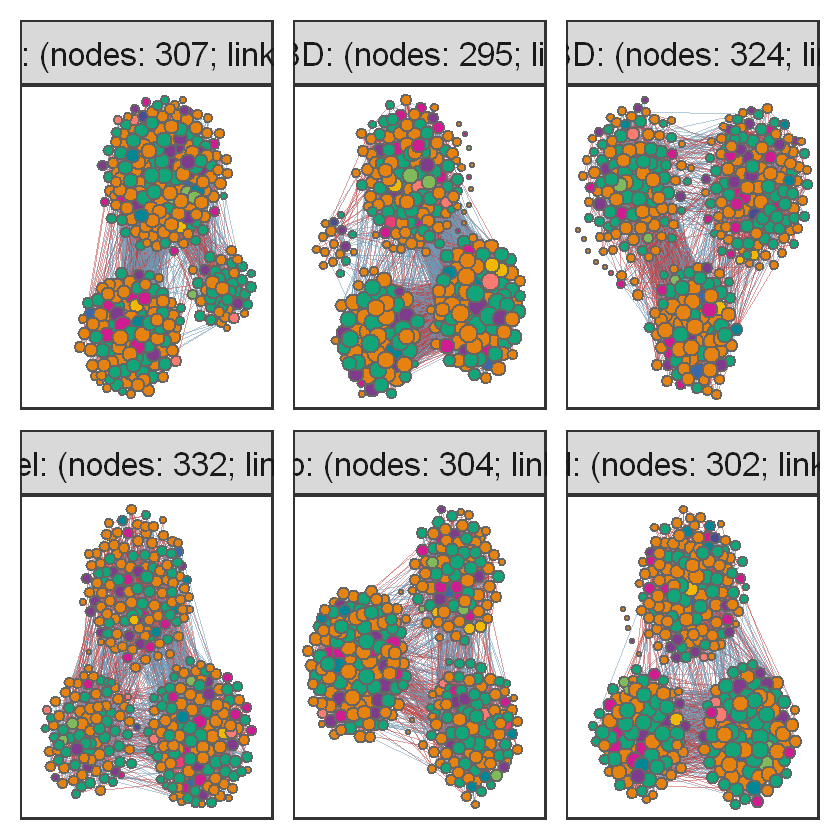

In [13]:
ggplot() + geom_segment(aes(x = X1, y = Y1, xend = X2, yend = Y2,color = cor),
data = edge, size = 0.03,alpha = 0.5) +
  geom_point(aes(X1, X2,
                 fill = phylum,
                 size = igraph.degree),
             pch = 21, data = node,color = "gray40") +
  facet_wrap(.~ label,scales="free_y",nrow = 2) +
  # geom_text_repel(aes(X1, X2,label = elements),pch = 21, data = nodeG) +
  # geom_text(aes(X1, X2,label = elements),pch = 21, data = nodeG) +
  scale_colour_manual(values = c("#6D98B5","#bd4242")) +
  scale_fill_manual(values = c("#7F3C8D","#11A579","#3969AC","#F2B701","#E73F74","#80BA5A","#E68310","#008695","#CF1C90","#f97b72","#4b4b8f", "#bdb5d7", "#7356b1", "#c29e64", "#e36f85", "#003c75", "#5d4f57")) +
  scale_size(range = c(1, 5)) +
  scale_x_continuous(breaks = NULL) +
  scale_y_continuous(breaks = NULL) +
  theme(panel.background = element_blank(),
        plot.title = element_text(hjust = 0.5)
  ) +
  theme(axis.title.x = element_blank(),
        axis.title.y = element_blank()
  ) +
  theme(legend.background = element_rect(colour = NA)) +
  theme(panel.background = element_rect(fill = "white",  colour = NA)) +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_blank()) +
  theme(legend.position = "none")
p
#ggsave("network_2026-3-10.pdf",p,width = 18,height = 8)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


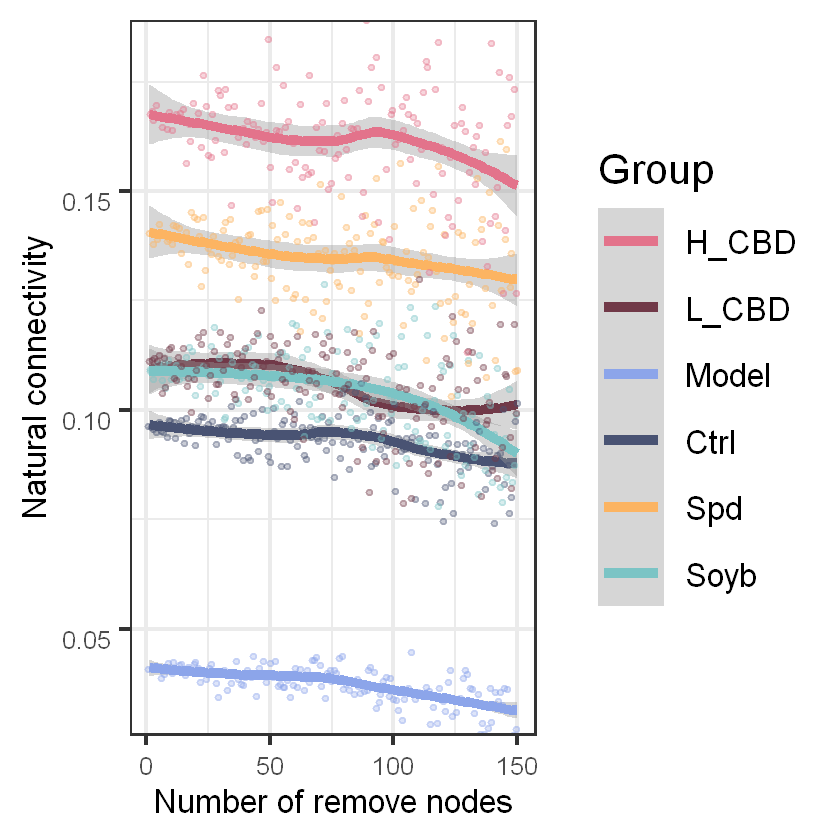

In [14]:
res$Group = factor(res$Group, levels = c("H_CBD","L_CBD","Model","Ctrl","Spd","Soyb"))
ggplot(res, aes(Num.of.remove.nodes, Natural.connectivity, group = Group, color = Group)) +
  geom_smooth(size = 3) +
  scale_color_manual(values = c("#E3738B","#713948","#8CA5EA","#495373","#FCB462","#7BC4C5")) +
  geom_jitter(alpha = 0.3,size = 1.3) +
  xlab("Number of remove nodes") +
  ylab("Natural connectivity") +
  my_theme +
  theme(axis.text.x = element_text(angle = 0)) +
  scale_y_continuous(expand = c(0,0))


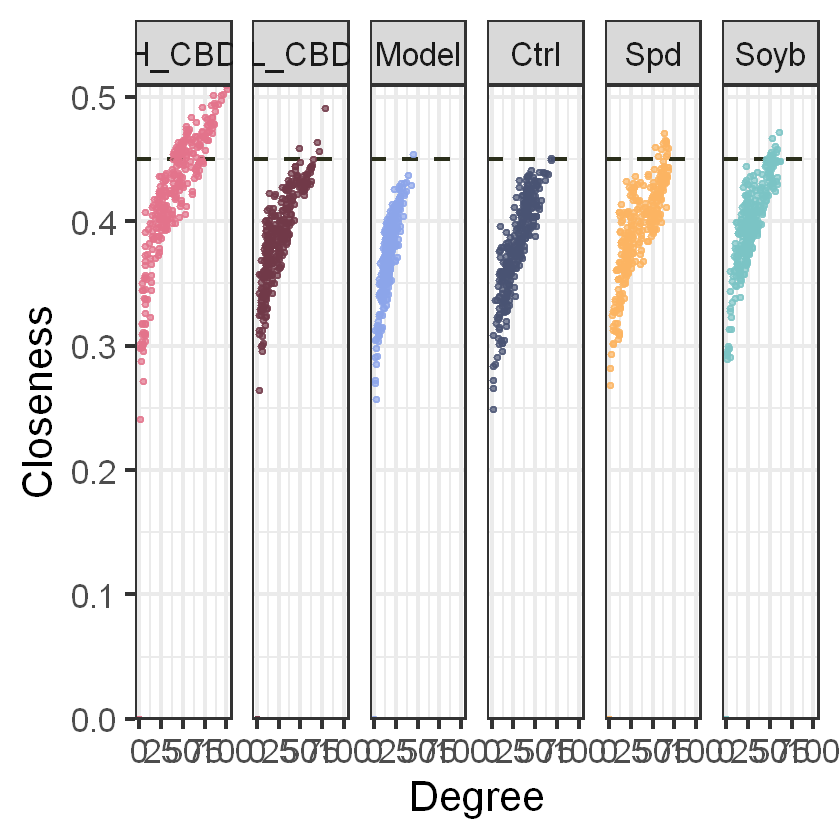

In [15]:
node$group = factor(node$group,levels = c("H_CBD","L_CBD","Model","Ctrl","Spd","Soyb"))
p_node <- ggplot(node, aes(igraph.degree, igraph.closeness,group = group, color = group)) +
  geom_hline(yintercept = 0.45, linewidth = 1.3, linetype = "dashed",color = "#2b2f1b") +
  geom_point(size = 1.2,alpha = 0.7) +
  scale_color_manual(values = c("#E3738B","#713948","#8CA5EA","#495373","#FCB462","#7BC4C5")) +
  facet_wrap(~group,nrow = 1) +
  theme(legend.position = "none") +
  scale_y_continuous(expand = c(0,0)) +
  xlab("Degree") +
  ylab("Closeness")
p_node 

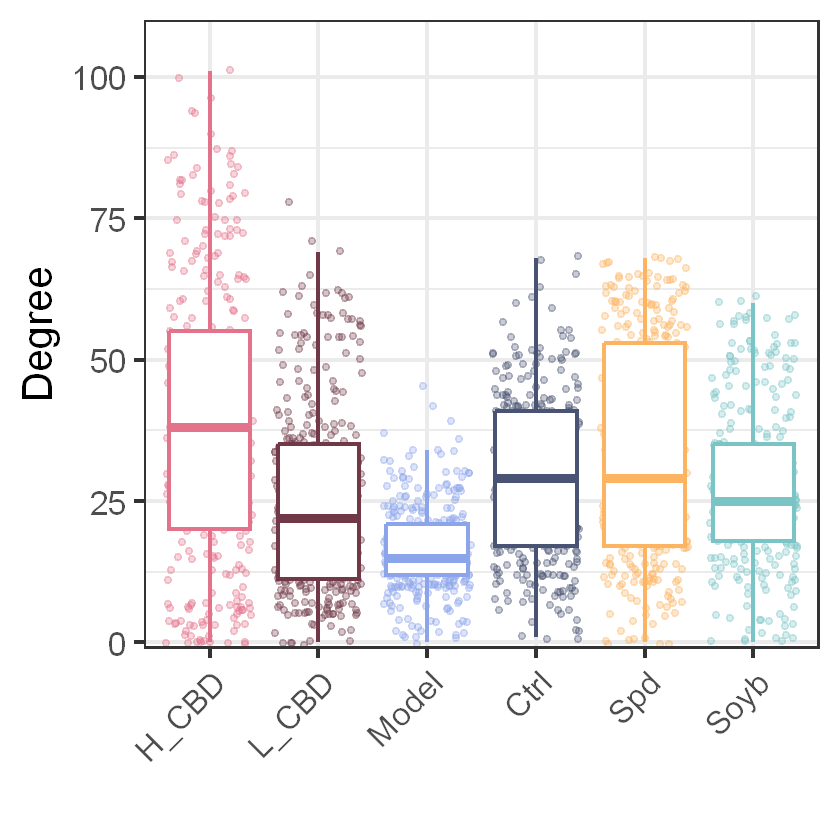

In [16]:
p_degree <- ggplot(node, aes(group, igraph.degree)) +
  geom_jitter(aes(color = group),alpha = 0.3,size = 1.6, show.legend = F) +
  geom_boxplot(aes(color = group),outlier.alpha = 0,size = 1.3,show.legend = F) +
  scale_color_manual(values = c("#E3738B","#713948","#8CA5EA","#495373","#FCB462","#7BC4C5")) +
  scale_fill_manual(values = c("#E3738B","#713948","#8CA5EA","#495373","#FCB462","#7BC4C5")) +
  #geom_signif(comparisons = list(c("H_CBD","L_CBD")),map_signif_level = T,size = 1.5) +
  scale_y_continuous(expand = c(0,0),limits = c(-1,110)) +
  ylab("Degree") +
  xlab("") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none")
p_degree